<a href="https://colab.research.google.com/github/DaveAUni/EnergyPovertyReproAss1/blob/main/MSCDampFinal_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# To what extent can household and dwelling characteristics be used to predict the risk of damp or mould in English homes using supervised machine learning models
# David Austin
# University of Birmingham - MSC AI and Sustainable Development

In [ ]:
# Install Python packages
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# Model selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
    learning_curve
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve
)

# Other models (optional)
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Utilities
from sklearn.utils import resample
from scipy.stats import randint, uniform


In [ ]:
# Directory

import os
os.getcwd()

'C:\\Users\\davea'

In [ ]:
# Load data
df_damp_model = pd.read_csv('clean_data.csv')

In [ ]:
#Info on data
df_damp_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10572 entries, 0 to 10571
Columns: 183 entries, fpLILEEflg to fpLIHCflg
dtypes: float64(19), int64(164)
memory usage: 14.8 MB


In [ ]:
# Data columns
df_damp_model.columns.tolist()

['fpLILEEflg',
 'AHCIncomeEQ_LILEE',
 'fpfullinc',
 'fuelexpn',
 'FuelCosteqFactor',
 'EqAHCincDeciles_LILEE',
 'elecmop',
 'gasmop',
 'aagph2021_x',
 'FPGAP_LILEE',
 'fpvuln',
 'fpLILEEqdt',
 'FPEERband',
 'FPEERrating',
 'DWtype',
 'DWage',
 'Ongas',
 'CentralHeating',
 'Mainfueltype',
 'boiler_x',
 'WallType',
 'tenure4x_fp',
 'Loftins',
 'EPC',
 'SAP12',
 'hhcompx_x',
 'Ageyng',
 'Ageold',
 'Hhsize',
 'ethhrp2x_x',
 'Hhsick',
 'Unoc',
 'emphrp3x_x',
 'ECO_AW',
 'FloorArea',
 'gorehs_x',
 'HTHG',
 'WHDBroad',
 'HousingCosts',
 'fpbasinc',
 'wathcost',
 'spahcost',
 'litecost',
 'cookcost',
 'BHCflg10',
 'AHCflg10',
 'FullincDeciles',
 'aagpd2021',
 'aagph2021_y',
 'tenure8x',
 'tenure4x',
 'tenure2x',
 'vacantx',
 'gorehs_y',
 'region3x',
 'govreg1',
 'hhcompx_y',
 'hhcomp1',
 'hhtype11',
 'hhtype7',
 'hhtype6',
 'hhsizex',
 'ndepchild',
 'noUnits1',
 'sft',
 'agehrp2x',
 'agehrp4x',
 'agehrp6x',
 'agepart6x',
 'ager',
 'pyngbx',
 'ageoldbx',
 'emphrpx',
 'emphrp3x_y',
 'nssech9',
 

In [ ]:
# INPUTS for Damp Prediction Algorithms

# Predictor Variables: Census‑proxy features
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",

    "fpLILEEflg","fpLIHCflg","HousingCosts",


]

# Target variable
target = "dampalfm"


In [ ]:
# DATA SPLIT x,y and test train
X = df_damp_model[list_census_proxy].copy()
y = df_damp_model['dampalfm'].copy()

# data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

# to separate the test set and only use it for the final evaluation

((8457, 18), (2115, 18), (8457,), (2115,))

In [ ]:
print(f"Overall damp rate: {y.mean() * 100:.2f}%")
print(f"Train damp rate: {y_train.mean() * 100:.2f}%")
print(f"Test damp rate: {y_test.mean() * 100:.2f}%")


Overall damp rate: 3.67%
Train damp rate: 3.67%
Test damp rate: 3.69%


In [ ]:
#FUNCTIONS
# Model section and handling imbalance data in classification
# Define a fixed Stratified K-Fold object (to make sure that the same folds are used for both model selection and hyperparameter tuning)
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
def select_models(X, y):
    """
    Model selection WITHOUT imblearn (compatible with your environment).
    Includes:
    - Logistic Regression (balanced)
    - Random Forest (balanced class weights)
    - XGBoost (scale_pos_weight)
    """

    start = time.time()
    scoring = ["accuracy", "balanced_accuracy"]

    # Preprocessor for RF + LR
    num_pipe_rf = make_pipeline(
        SimpleImputer(strategy="mean", add_indicator=True),
        StandardScaler()
    )
    cat_pipe_rf = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="missing"),
        OneHotEncoder(handle_unknown="ignore")
    )
    preprocessor_rf = make_column_transformer(
        (num_pipe_rf, selector(dtype_include="number")),
        (cat_pipe_rf, selector(dtype_include="category")),
        n_jobs=-1
    )

    # Preprocessor for XGB
    num_pipe_xgb = make_pipeline(
        SimpleImputer(strategy="mean", add_indicator=True),
        StandardScaler()
    )
    cat_pipe_xgb = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="missing"),
        OneHotEncoder(handle_unknown="ignore")
    )
    preprocessor_xgb = make_column_transformer(
        (num_pipe_xgb, selector(dtype_include="number")),
        (cat_pipe_xgb, selector(dtype_include="category")),
        n_jobs=-1
    )

    index = []
    scores = {"Accuracy": [], "Balanced accuracy": []}

    # Logistic Regression
    lr_clf = Pipeline([
        ("preprocessor", preprocessor_rf),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])
    index.append("Logistic Regression (balanced)")
    cv_result = cross_validate(lr_clf, X, y, scoring=scoring, cv=5)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # Random Forest (balanced)
    rf_clf = Pipeline([
        ("preprocessor", preprocessor_rf),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])
    index.append("Random forest with balanced class weights")
    cv_result = cross_validate(rf_clf, X, y, scoring=scoring, cv=5)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    # XGBoost (scale_pos_weight)
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    scale_pos_weight = neg / pos

    xgb_clf = Pipeline([
        ("preprocessor", preprocessor_xgb),
        ("model", XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            random_state=42,
            n_jobs=-1
        ))
    ])
    index.append("XGBoost with scale_pos_weight")
    cv_result = cross_validate(xgb_clf, X, y, scoring=scoring, cv=5)
    scores["Accuracy"].append(cv_result["test_accuracy"].mean())
    scores["Balanced accuracy"].append(cv_result["test_balanced_accuracy"].mean())

    df_scores = pd.DataFrame(scores, index=index)

    end = time.time()
    print(f"Time elapsed: {end - start:.2f} s")

    return df_scores, xgb_clf, preprocessor_xgb, scale_pos_weight


In [ ]:
# Optimized function for xgb model hyperparameter tuning

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

def tune_xgboost(selected_model, preprocessor_xgb, scale_pos_weight, X_train, y_train, n_iter=30):
    """
    Tunes hyperparameters for the selected XGBoost model with preprocessing inside a pipeline.

    Parameters:
    - selected_model: The model chosen from model selection (Pipeline with XGBoost)
    - preprocessor_xgb: The preprocessor for XGBoost (ColumnTransformer)
    - scale_pos_weight: The computed class imbalance ratio from model selection
    - X_train: Training features
    - y_train: Training labels
    - n_iter: Number of hyperparameter combinations to test (default=30)

    Returns:
    - best_model: The best hyperparameter-tuned XGBoost model (Pipeline)
    - best_params: Best hyperparameters found
    """

    print("Hyperparameter tuning with RandomizedSearchCV")

    # Extract preprocessing step from the selected pipeline
    preprocessor = preprocessor_xgb # Ensure this matches pipeline step name

    # Rebuild the model with scale_pos_weight fixed
    xgb_tune = XGBClassifier(
        scale_pos_weight=scale_pos_weight,  # Ensure it is retained!
        random_state=42,
        n_jobs=-1
    )

    # Define full pipeline (preprocessing + model)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Include preprocessing step
        ('xgb', xgb_tune)  # XGBoost model
    ])

    # Define hyperparameter search space (corrected with "xgb__" prefix)
    param_dist = {
        'xgb__n_estimators': randint(100, 500),
        'xgb__learning_rate': uniform(0.01, 0.3),
        'xgb__max_depth': randint(3, 12),
        'xgb__subsample': uniform(0.5, 0.5),
        'xgb__colsample_bytree': uniform(0.5, 0.5),
        'xgb__gamma': uniform(0, 5),
        'xgb__reg_lambda': uniform(0, 10),
        'xgb__reg_alpha': uniform(0, 10)
    }

    # Setup RandomizedSearchCV (using the same CV folds as model selection)
    random_search = RandomizedSearchCV(
        estimator=pipeline,  # Tune the entire pipeline (preprocessor + XGBoost)
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv_folds,  # Ensure same cross-validation folds as model selection
        scoring='balanced_accuracy',
        n_jobs=-1,
        random_state=42
    )

    # Fit RandomizedSearchCV
    random_search.fit(X_train, y_train)

    # Extract best pipeline (preprocessing + tuned XGB)
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score = random_search.best_score_

    # Print results
    print("\nHyperparameter Tuning Complete")
    print("Best Hyperparameters:", best_params)
    print(f"Best Balanced Accuracy: {best_score:.4f}")

    return best_model, best_params

In [ ]:
# Set custom threshold for confusion matrix

def tune_classification_threshold(best_model, X_test, y_test, set_threshold=0.5, risk_label=1):
    """
    Tunes classification threshold and evaluates model performance.

    Parameters:
    - best_model: Trained classifier with `predict_proba()`
    - X_test: pd.DataFrame - Test set features
    - y_test: pd.Series - True labels for test set
    - set_threshold: float - The threshold to use for final evaluation (default=0.5)
    - risk_label: int - The class label for "at risk" classification (default=1)

    Returns:
    - best_threshold: float - Optimal threshold for highest F1 score
    - metrics_at_custom_threshold: dict - Evaluation metrics at custom threshold
    """

    print("Tuning classification threshold")

    # Get probabilities for each class
    probs = best_model.predict_proba(X_test)

    # Define threshold values
    thresholds = np.linspace(0, 1, 101)  # Generate 101 thresholds from 0 to 1

    # Initialize lists to store metrics
    f1_scores = []
    precisions = []
    recalls = []
    specificities = []
    accuracies = []

    # Loop through each threshold and compute metrics
    for threshold in thresholds:
        preds = (probs[:, risk_label] >= threshold).astype(int)

        # Compute confusion matrix components
        tn, fp, fn, tp = confusion_matrix(y_test == risk_label, preds).ravel()

        # Compute metrics safely (avoid division by zero)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = accuracy_score(y_test == risk_label, preds)

        # Store results
        f1_scores.append(f1)
        precisions.append(precision)
        recalls.append(recall)
        specificities.append(specificity)
        accuracies.append(accuracy)

    # Find the best threshold (based on F1-score)
    best_f1 = max(f1_scores)
    best_threshold = thresholds[f1_scores.index(best_f1)]
    print(f"\n🔹 Best threshold for highest F1-score: {best_threshold:.2f}")

    # Define the custom threshold
    custom_threshold = set_threshold

    # Evaluate model at the custom threshold
    best_preds = (probs[:, risk_label] >= custom_threshold).astype(int)
    cm = confusion_matrix(y_test == risk_label, best_preds)

    # Plot all metrics against threshold
    plt.figure(figsize=(10, 8))
    plt.plot(thresholds, f1_scores, label="F1 Score", marker='.')
    plt.plot(thresholds, precisions, label="Precision", marker='.')
    plt.plot(thresholds, recalls, label="Recall", marker='.')
    plt.plot(thresholds, specificities, label="Specificity", marker='.')
    plt.plot(thresholds, accuracies, label="Accuracy", marker='.')
    plt.axvline(custom_threshold, color='black', linestyle='--', label=f"Custom Threshold ({custom_threshold:.2f})")
    # plt.axvline(best_threshold, color='g', linestyle='--', label=f"Best F1 Threshold ({best_threshold:.2f})")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Model Metrics vs. Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Classification report at the selected custom threshold
    print(f"\n🔹 Classification report at custom threshold ({custom_threshold:.2f}):")
    print(classification_report(y_test == risk_label, best_preds, target_names=['Not at risk', 'At risk']))

    # Compute balanced accuracy
    bal_acc = balanced_accuracy_score(y_test == risk_label, best_preds)
    print(f"🔹 Balanced Accuracy at threshold {custom_threshold:.2f}: {bal_acc:.4f}")

    # Store results in a dictionary
    metrics_at_custom_threshold = {
        "Custom Threshold": custom_threshold,
        "Best F1 Threshold": best_threshold,
        "Balanced Accuracy": bal_acc,
        "F1 Score": f1_scores[thresholds.tolist().index(custom_threshold)],
        "Precision": precisions[thresholds.tolist().index(custom_threshold)],
        "Recall": recalls[thresholds.tolist().index(custom_threshold)],
        "Specificity": specificities[thresholds.tolist().index(custom_threshold)],
        "Accuracy": accuracies[thresholds.tolist().index(custom_threshold)],
        "Confusion Matrix": cm
    }

    return best_threshold, metrics_at_custom_threshold

In [ ]:
# Main Predictors

# select inputs and target variable – use only train set for model selection
df_res = X_train[list_census_proxy].copy()
y_res = y_train.copy()

# compare model selection results, get the best selected model (xgb),
# the xgb preprocessor, and scale_pos_weight
df_scores, select_model, preprocessor_xgb, scale_pos_weight = select_models(df_res, y_res)

df_scores


Time elapsed: 57.58 s


,Accuracy,Balanced accuracy
Logistic Regression (balanced),0.792008,0.788094
Random forest with balanced class weights,0.957195,0.593004
XGBoost with scale_pos_weight,0.904104,0.725256


In [ ]:
# --- Numeric preprocessing ---
num_pipe_xgb = make_pipeline(
    SimpleImputer(strategy="mean", add_indicator=True),
    StandardScaler()
)

# --- Categorical preprocessing ---
cat_pipe_xgb = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore")
)

# --- Column transformer ---
preprocessor_xgb = make_column_transformer(
    (num_pipe_xgb, X_train.select_dtypes(include="number").columns),
    (cat_pipe_xgb, X_train.select_dtypes(include="category").columns),
    n_jobs=-1
)

# --- Compute class imbalance weight ---
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# --- Tuned XGBoost model ---
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=354,
    learning_rate=0.238,
    max_depth=3,
    min_child_weight=6,
    gamma=3.36,
    subsample=0.9917,
    colsample_bytree=0.621,
    reg_alpha=8.03,
    reg_lambda=4.70,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# --- Final pipeline ---
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("model", xgb_model)
])

print("Pipeline successfully rebuilt ✔")


Pipeline successfully rebuilt ✔


In [ ]:
# --- Train tuned XGBoost model ---

xgb_pipeline.fit(X_train, y_train)

# --- Predict probabilities on the test set ---
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# --- Default threshold evaluation (0.5) ---
y_pred_default = (y_proba >= 0.5).astype(int)

print("Default Threshold (0.5) Performance")
print(classification_report(y_test, y_pred_default))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_default))

# --- Threshold tuning for best balanced accuracy ---
thresholds = np.linspace(0.05, 0.50, 91)
best_bal_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    bal_acc = balanced_accuracy_score(y_test, preds)
    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.3f}")
print(f"Best Balanced Accuracy: {best_bal_acc:.4f}")

# --- Evaluate at best threshold ---
y_pred_best = (y_proba >= best_threshold).astype(int)

print("\nPerformance at Best Threshold")
print(classification_report(y_test, y_pred_best))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# --- Evaluate at threshold 0.75 ---
fixed_threshold = 0.75
y_pred_075 = (y_proba >= fixed_threshold).astype(int)

print("\nPerformance at Threshold 0.75")
print(classification_report(y_test, y_pred_075))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_075))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_075))




Default Threshold (0.5) Performance
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      2037
           1       0.15      0.69      0.25        78

    accuracy                           0.84      2115
   macro avg       0.57      0.77      0.58      2115
weighted avg       0.96      0.84      0.89      2115

Balanced Accuracy: 0.7715343076167818

Best Threshold: 0.350
Best Balanced Accuracy: 0.7796

Performance at Best Threshold
              precision    recall  f1-score   support

           0       0.99      0.78      0.87      2037
           1       0.12      0.78      0.21        78

    accuracy                           0.78      2115
   macro avg       0.55      0.78      0.54      2115
weighted avg       0.96      0.78      0.85      2115

Balanced Accuracy: 0.7795872512367358
Confusion Matrix:
[[1583  454]
 [  17   61]]

Performance at Threshold 0.75
              precision    recall  f1-score   support

           0      

ROC AUC: 0.85


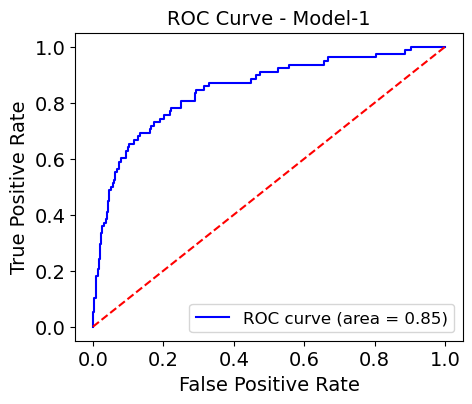

In [ ]:
# Calculate ROC AUC score
#  "at risk" is class 1
double_risk_label = 1
# Get probabilities for each class
probs = xgb_pipeline.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, probs[:, double_risk_label])
print(f"ROC AUC: {roc_auc:.2f}")

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probs[:, double_risk_label])

# Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

# Adjust font sizes
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve - Model-1", fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig('./plots_of_results/roc_curve_com_1.png', dpi=300, bbox_inches='tight')
plt.show()

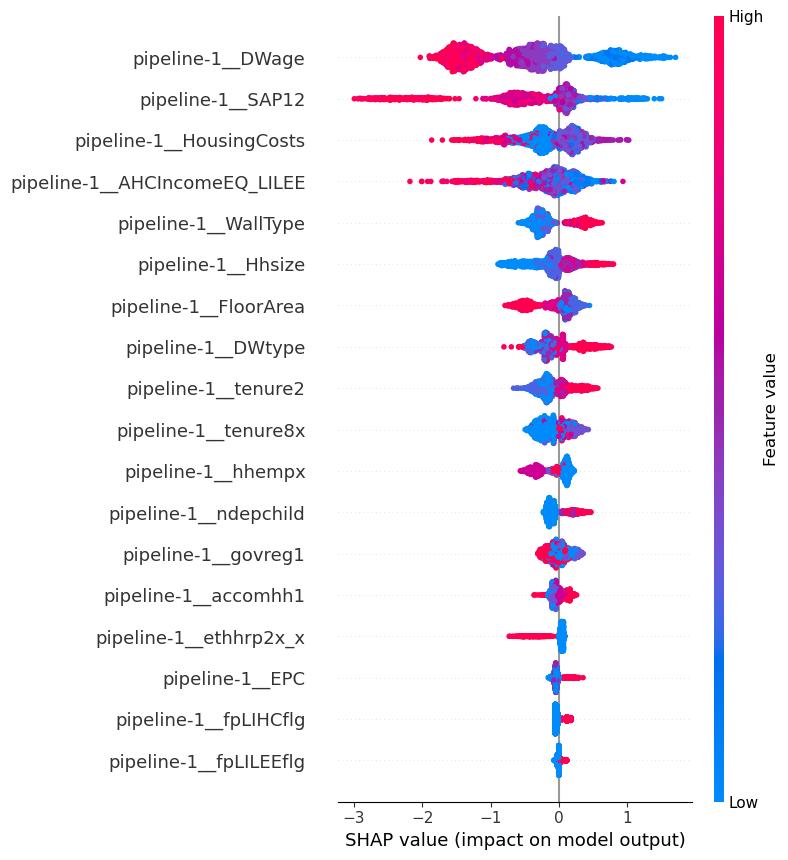

In [ ]:
import shap

# -----------------------------
# 1. DEFINE FEATURE SET
# -----------------------------
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",
    "fpLILEEflg","fpLIHCflg","HousingCosts",
]

# -----------------------------
# 2. BUILD TRAIN / TEST USING SAME COLUMNS
# -----------------------------
X_train = X_train[list_census_proxy].copy()
y_train = y_train.copy()

X_test = X_test[list_census_proxy].copy()
y_test = y_test.copy()

# -----------------------------
# 3. EXTRACT MODEL + PREPROCESSOR
# -----------------------------
xgb_model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Transform X_test into numeric matrix for SHAP
X_test_transformed = preprocessor.transform(X_test)

# -----------------------------
# 4. SHAP EXPLAINER + VALUES
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# -----------------------------
# 5. SHAP SUMMARY PLOT
# -----------------------------
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)


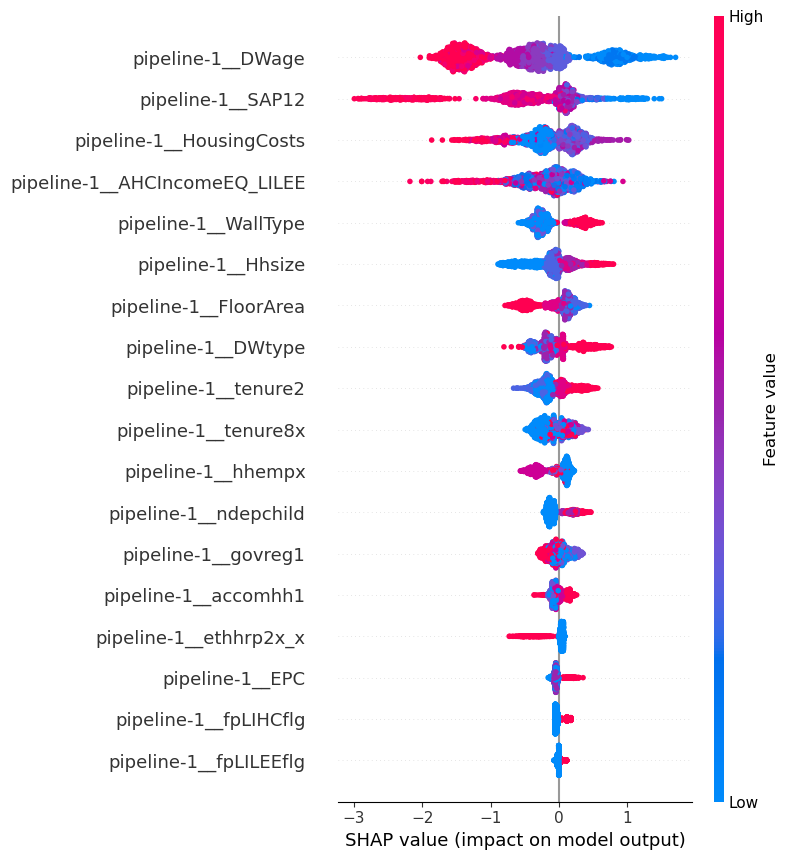

In [ ]:
import shap

# -----------------------------
# 1. DEFINE FEATURE SET
# -----------------------------
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",
    "fpLILEEflg","fpLIHCflg","HousingCosts",
]

# -----------------------------
# 2. BUILD SHAP INPUTS (do NOT overwrite X_train/X_test)
# -----------------------------
X_train_shap = X_train[list_census_proxy].copy()
y_train_shap = y_train.copy()

X_test_shap = X_test[list_census_proxy].copy()
y_test_shap = y_test.copy()

# -----------------------------
# 3. EXTRACT MODEL + PREPROCESSOR
# -----------------------------
xgb_model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Transform X_test into numeric matrix for SHAP
X_test_transformed = preprocessor.transform(X_test_shap)

# -----------------------------
# 4. SHAP EXPLAINER + VALUES
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# -----------------------------
# 5. SHAP SUMMARY PLOT
# -----------------------------
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)




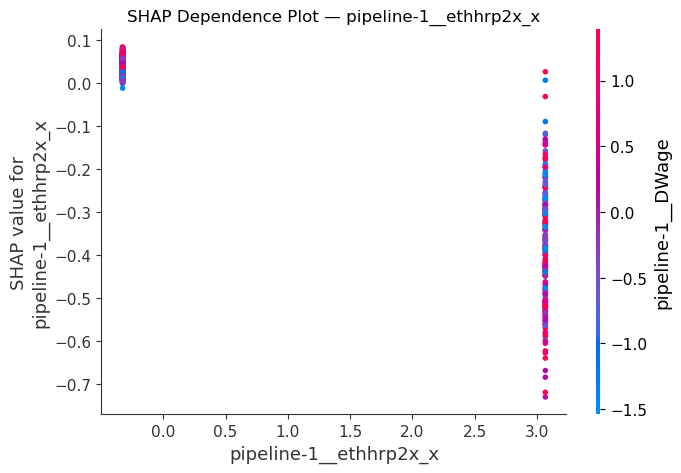

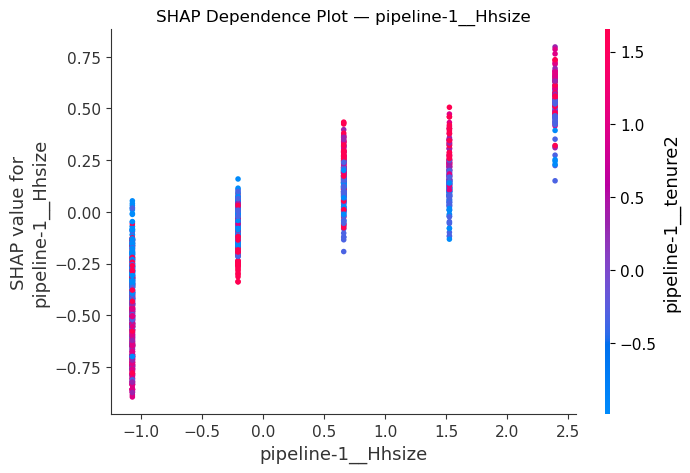

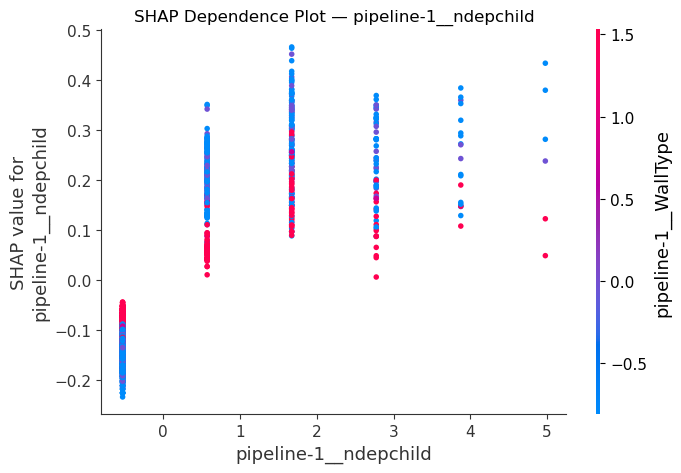

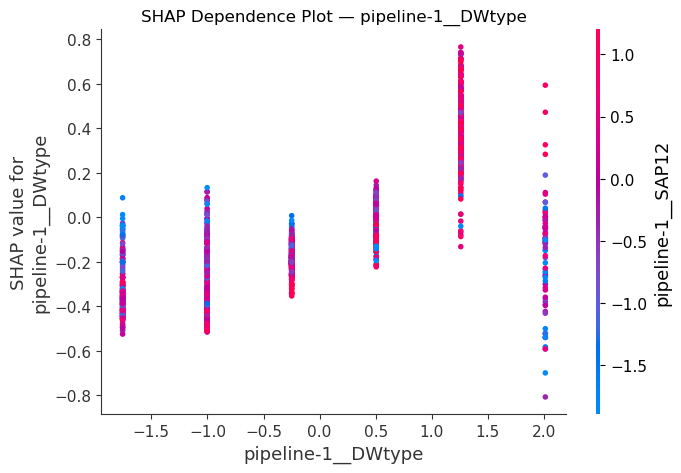

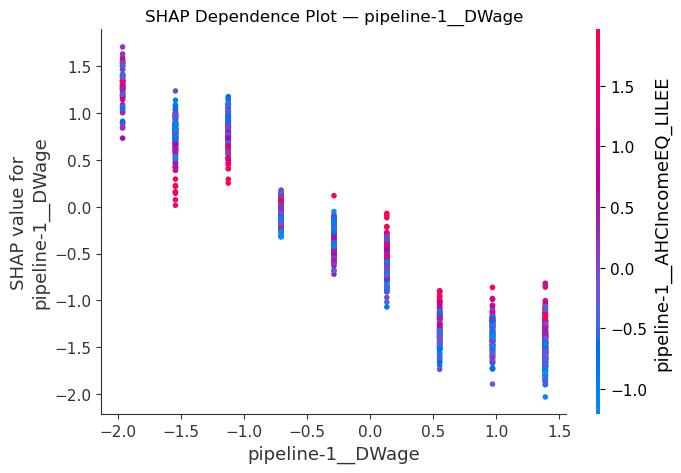

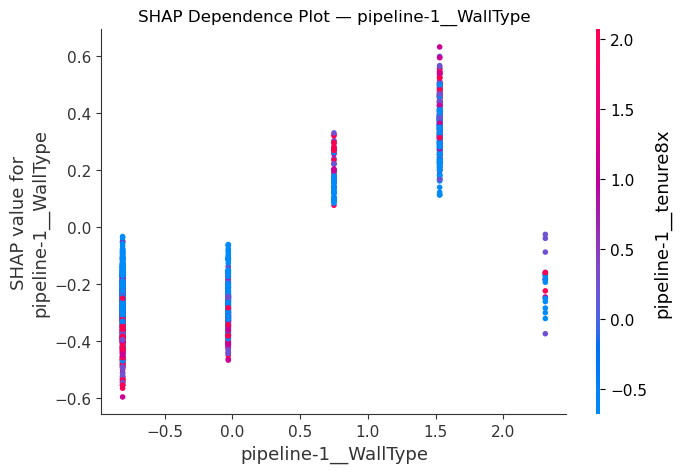

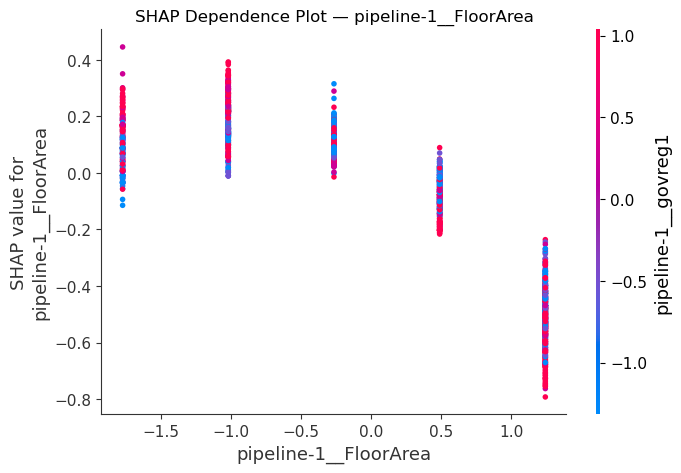

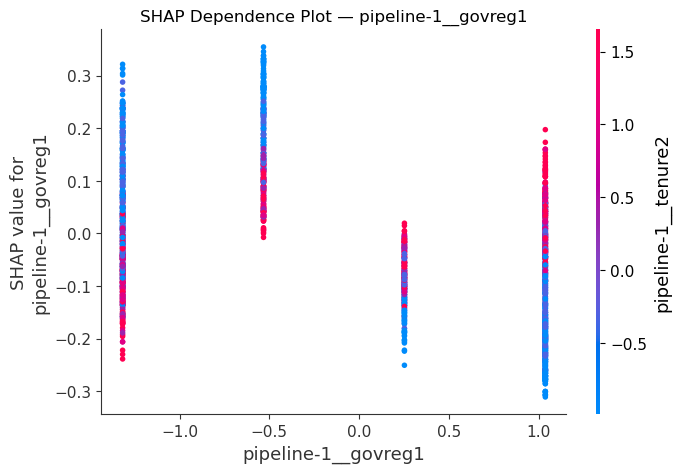

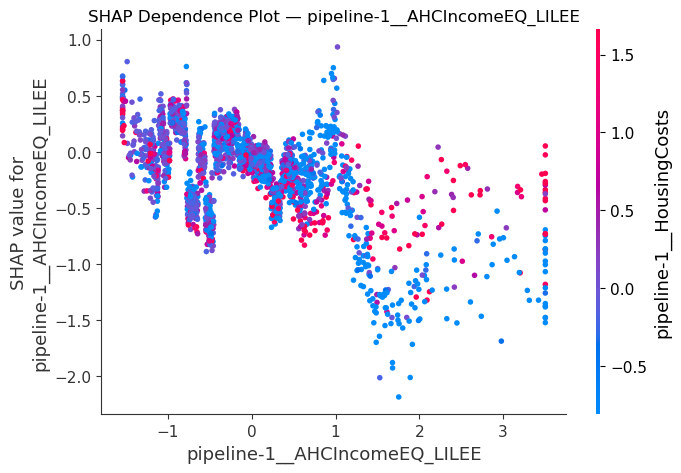

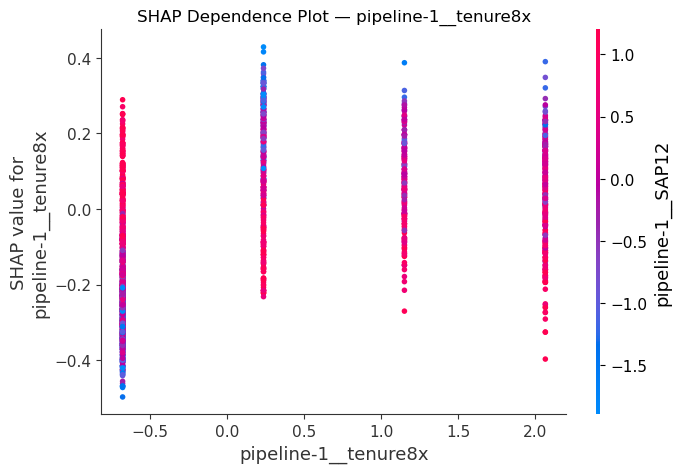

In [ ]:
# ---------------------------------------------------------
# SHAP DEPENDENCE PLOTS (TOP FEATURES)
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Select top N features (based on SHAP importance order)
top_features = feature_names[:10]   # or manually pick: ["SAP12", "EPC", "FloorArea", ...]

for feat in top_features:
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_transformed,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Dependence Plot — {feat}")
    plt.show()


# ---------------------------------------------------------
# SHAP FORCE PLOTS FOR INDIVIDUAL HOUSEHOLDS
# ---------------------------------------------------------

# Example: pick a specific household index
index = 0   # change to any row index in X_test

# Force plot for a single prediction
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[index, :],
    X_test_transformed[index, :],
    feature_names=feature_names
)



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, brier_score_loss

# ---------------------------------------------------------
# 1. Extract model + preprocessor
# ---------------------------------------------------------
model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# ---------------------------------------------------------
# 2. Transform test data
# ---------------------------------------------------------
X_test_transformed = preprocessor.transform(X_test[list_census_proxy])
y_true = y_test.copy()

# ---------------------------------------------------------
# 3. Predict probabilities + apply tuned threshold
# ---------------------------------------------------------
y_prob = model.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# ---------------------------------------------------------
# 4. Define subgroup variables
# ---------------------------------------------------------
subgroups = {
    "Tenure": X_test["tenure2"],
    "Income": X_test["AHCIncomeEQ_LILEE"],
    "Region": X_test["govreg1"],
    "HouseSize": X_test["Hhsize"],
    "Ethnicity": X_test["ethhrp2x_x"]
}

# ---------------------------------------------------------
# 5. Function to compute subgroup metrics
# ---------------------------------------------------------
def subgroup_metrics(y_true, y_pred, y_prob, group):
    results = []

    for value in np.sort(group.unique()):
        idx = group == value

        if idx.sum() == 0:
            continue

        yt = y_true[idx]
        yp = y_pred[idx]
        yp_prob = y_prob[idx]

        recall = recall_score(yt, yp, zero_division=0)
        fnr = 1 - recall
        brier = brier_score_loss(yt, yp_prob)

        # calibration difference: predicted risk minus actual rate
        calib = yp_prob.mean() - yt.mean()

        results.append({
            "Group": value,
            "Count": idx.sum(),
            "Recall": recall,
            "False Negative Rate": fnr,
            "Brier Score": brier,
            "Calibration Difference": calib
        })

    return pd.DataFrame(results)

# ---------------------------------------------------------
# 6. Run subgroup analysis for each variable
# ---------------------------------------------------------
tables = {}

for name, group in subgroups.items():
    tables[name] = subgroup_metrics(y_true, y_pred, y_prob, group)

# ---------------------------------------------------------
# 7. Display results
# ---------------------------------------------------------
for name, table in tables.items():
    print(f"\n=== Subgroup Fairness: {name} ===")
    display(table)




=== Subgroup Fairness: Tenure ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,711,0.714286,0.285714,0.046876,0.114686
1,2,568,0.300000,0.700000,0.094683,0.185095
2,3,190,1.000000,0.000000,0.158520,0.280601
3,4,296,0.555556,0.444444,0.122502,0.212224
4,5,308,0.966667,0.033333,0.221283,0.313449
5,6,42,0.875000,0.125000,0.199144,0.213691



=== Subgroup Fairness: Income ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,0,28,1.0,0.0,0.205774,0.279212
1,73,1,0.0,1.0,0.109650,0.331135
2,224,1,0.0,1.0,0.518465,0.720045
3,319,1,0.0,1.0,0.002045,0.045218
4,394,1,0.0,1.0,0.018553,0.136210
...,...,...,...,...,...,...
2004,95747,1,0.0,1.0,0.000119,0.010895
2005,96215,1,0.0,1.0,0.000576,0.024003
2006,98387,1,0.0,1.0,0.000399,0.019979
2007,99169,1,0.0,1.0,0.000037,0.006083



=== Subgroup Fairness: Region ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,666,0.800000,0.200000,0.120522,0.215312
1,2,337,0.875000,0.125000,0.139327,0.234415
2,3,257,0.692308,0.307692,0.101490,0.173678
3,4,855,0.736842,0.263158,0.089712,0.165256



=== Subgroup Fairness: HouseSize ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,635,0.842105,0.157895,0.098047,0.178844
1,2,837,0.695652,0.304348,0.089699,0.169516
2,3,298,0.785714,0.214286,0.130613,0.230486
3,4,237,0.833333,0.166667,0.121137,0.209293
4,5,108,0.800000,0.200000,0.231825,0.320252



=== Subgroup Fairness: Ethnicity ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,1886,0.787879,0.212121,0.110069,0.195398
1,2,229,0.750000,0.250000,0.097893,0.173819


In [ ]:
# ---------------------------------------------------------
# Combined subgroup fairness table
# ---------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, brier_score_loss

# 1. Extract model + preprocessor
model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# 2. Transform test data
X_test_transformed = preprocessor.transform(X_test[list_census_proxy])
y_true = y_test.copy()

# 3. Predict probabilities + apply tuned threshold
y_prob = model.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# 4. Define subgroup variables
subgroups = {
    "Tenure": X_test["tenure2"],
    "Household Size": X_test["Hhsize"],
    "Region": X_test["govreg1"],
    "Ethnicity": X_test["ethhrp2x_x"]
}

# 5. Function to compute subgroup metrics
def subgroup_metrics(y_true, y_pred, y_prob, group, group_name):
    rows = []
    for value in np.sort(group.unique()):
        idx = group == value
        if idx.sum() == 0:
            continue

        yt = y_true[idx]
        yp = y_pred[idx]
        yp_prob = y_prob[idx]

        recall = recall_score(yt, yp, zero_division=0)
        fnr = 1 - recall
        brier = brier_score_loss(yt, yp_prob)
        calib = yp_prob.mean() - yt.mean()

        rows.append({
            "Subgroup": group_name,
            "Group Value": value,
            "Count": idx.sum(),
            "Recall": recall,
            "False Negative Rate": fnr,
            "Brier Score": brier,
            "Calibration Difference": calib
        })
    return pd.DataFrame(rows)

# 6. Build one combined table
combined_table = pd.concat(
    [subgroup_metrics(y_true, y_pred, y_prob, g, name) for name, g in subgroups.items()],
    ignore_index=True
)

# 7. Display single table
display(combined_table)


,Subgroup,Group Value,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,Tenure,1,711,0.714286,0.285714,0.046876,0.114686
1,Tenure,2,568,0.300000,0.700000,0.094683,0.185095
2,Tenure,3,190,1.000000,0.000000,0.158520,0.280601
3,Tenure,4,296,0.555556,0.444444,0.122502,0.212224
4,Tenure,5,308,0.966667,0.033333,0.221283,0.313449
5,Tenure,6,42,0.875000,0.125000,0.199144,0.213691
6,Household Size,1,635,0.842105,0.157895,0.098047,0.178844
7,Household Size,2,837,0.695652,0.304348,0.089699,0.169516
8,Household Size,3,298,0.785714,0.214286,0.130613,0.230486
9,Household Size,4,237,0.833333,0.166667,0.121137,0.209293


In [ ]:
# ---------------------------------------------------------
# Table 7: Subgroup Fairness Metrics
# ---------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, brier_score_loss

# 1. Extract model + preprocessor
model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# 2. Transform test data
X_test_transformed = preprocessor.transform(X_test[list_census_proxy])
y_true = y_test.copy()

# 3. Predict probabilities + apply tuned threshold
y_prob = model.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# 4. Define subgroup variables (income excluded)
subgroups = {
    "Tenure": X_test["tenure2"],
    "Region": X_test["govreg1"],
    "Household Size": X_test["Hhsize"],
    "Ethnicity": X_test["ethhrp2x_x"]
}

# 5. Function to compute subgroup fairness metrics
def subgroup_metrics(y_true, y_pred, y_prob, group, group_name):
    rows = []
    for value in np.sort(group.unique()):
        idx = group == value
        if idx.sum() == 0:
            continue

        yt = y_true[idx]
        yp = y_pred[idx]
        yp_prob = y_prob[idx]

        recall = recall_score(yt, yp, zero_division=0)
        fnr = 1 - recall
        brier = brier_score_loss(yt, yp_prob)
        calib = yp_prob.mean() - yt.mean()

        rows.append({
            "Subgroup": group_name,
            "Group Value": value,
            "Count": idx.sum(),
            "Recall": recall,
            "False Negative Rate": fnr,
            "Brier Score": brier,
            "Calibration Difference": calib
        })
    return pd.DataFrame(rows)

# 6. Build combined fairness table (Table 7)
table7 = pd.concat(
    [subgroup_metrics(y_true, y_pred, y_prob, g, name) for name, g in subgroups.items()],
    ignore_index=True
)

# 7. Display Table 7
display(table7)


,Subgroup,Group Value,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,Tenure,1,711,0.714286,0.285714,0.046876,0.114686
1,Tenure,2,568,0.300000,0.700000,0.094683,0.185095
2,Tenure,3,190,1.000000,0.000000,0.158520,0.280601
3,Tenure,4,296,0.555556,0.444444,0.122502,0.212224
4,Tenure,5,308,0.966667,0.033333,0.221283,0.313449
5,Tenure,6,42,0.875000,0.125000,0.199144,0.213691
6,Region,1,666,0.800000,0.200000,0.120522,0.215312
7,Region,2,337,0.875000,0.125000,0.139327,0.234415
8,Region,3,257,0.692308,0.307692,0.101490,0.173678
9,Region,4,855,0.736842,0.263158,0.089712,0.165256


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, brier_score_loss

# ---------------------------------------------------------
# 1. Extract model + preprocessor
# ---------------------------------------------------------
model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# ---------------------------------------------------------
# 2. Transform test data
# ---------------------------------------------------------
X_test_transformed = preprocessor.transform(X_test[list_census_proxy])
y_true = y_test.copy()

# ---------------------------------------------------------
# 3. Predict probabilities + apply tuned threshold
# ---------------------------------------------------------
y_prob = model.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# ---------------------------------------------------------
# 4. Define subgroup variables
# ---------------------------------------------------------
subgroups = {
    "tenure2": X_test["tenure2"],
    "household size": X_test["Hhsize"],
    "region": X_test["govreg1"],
    "ethnicity ": X_test["ethhrp2x_x"]
}

# ---------------------------------------------------------
# 5. Function to compute subgroup metrics
# ---------------------------------------------------------
def subgroup_metrics(y_true, y_pred, y_prob, group):
    results = []

    for value in np.sort(group.unique()):
        idx = group == value

        if idx.sum() == 0:
            continue

        yt = y_true[idx]
        yp = y_pred[idx]
        yp_prob = y_prob[idx]

        recall = recall_score(yt, yp, zero_division=0)
        fnr = 1 - recall
        brier = brier_score_loss(yt, yp_prob)

        # calibration difference: predicted risk minus actual rate
        calib = yp_prob.mean() - yt.mean()

        results.append({
            "Group": value,
            "Count": idx.sum(),
            "Recall": recall,
            "False Negative Rate": fnr,
            "Brier Score": brier,
            "Calibration Difference": calib
        })

    return pd.DataFrame(results)

# ---------------------------------------------------------
# 6. Run subgroup analysis for each variable
# ---------------------------------------------------------
tables = {}

for name, group in subgroups.items():
    tables[name] = subgroup_metrics(y_true, y_pred, y_prob, group)

# ---------------------------------------------------------
# 7. Display results
# ---------------------------------------------------------
for name, table in tables.items():
    print(f"\n=== Subgroup Fairness: {name} ===")
    display(table)



=== Subgroup Fairness: tenure2 ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,711,0.714286,0.285714,0.046876,0.114686
1,2,568,0.300000,0.700000,0.094683,0.185095
2,3,190,1.000000,0.000000,0.158520,0.280601
3,4,296,0.555556,0.444444,0.122502,0.212224
4,5,308,0.966667,0.033333,0.221283,0.313449
5,6,42,0.875000,0.125000,0.199144,0.213691



=== Subgroup Fairness: household size ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,635,0.842105,0.157895,0.098047,0.178844
1,2,837,0.695652,0.304348,0.089699,0.169516
2,3,298,0.785714,0.214286,0.130613,0.230486
3,4,237,0.833333,0.166667,0.121137,0.209293
4,5,108,0.800000,0.200000,0.231825,0.320252



=== Subgroup Fairness: region ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,666,0.800000,0.200000,0.120522,0.215312
1,2,337,0.875000,0.125000,0.139327,0.234415
2,3,257,0.692308,0.307692,0.101490,0.173678
3,4,855,0.736842,0.263158,0.089712,0.165256



=== Subgroup Fairness: ethnicity  ===


,Group,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,1,1886,0.787879,0.212121,0.110069,0.195398
1,2,229,0.750000,0.250000,0.097893,0.173819


In [ ]:
# ---------------------------------------------------------
# Fairness Analysis (Recall-focused) – Highest & Lowest Groups
# ---------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, brier_score_loss

# 1. Extract model + preprocessor
model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# 2. Transform test data
X_test_transformed = preprocessor.transform(X_test[list_census_proxy])
y_true = y_test.copy()

# 3. Predict probabilities + apply tuned threshold
y_prob = model.predict_proba(X_test_transformed)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# 4. Define subgroup variables (income excluded)
subgroups = {
    "Tenure": X_test["tenure2"],
    "Region": X_test["govreg1"],
    "Household Size": X_test["Hhsize"],
    "Ethnicity": X_test["ethhrp2x_x"]
}

# 5. Function to compute subgroup fairness metrics
def subgroup_metrics(y_true, y_pred, y_prob, group, group_name):
    rows = []
    for value in np.sort(group.unique()):
        idx = group == value
        if idx.sum() == 0:
            continue

        yt = y_true[idx]
        yp = y_pred[idx]
        yp_prob = y_prob[idx]

        recall = recall_score(yt, yp, zero_division=0)
        fnr = 1 - recall
        brier = brier_score_loss(yt, yp_prob)
        calib = yp_prob.mean() - yt.mean()

        rows.append({
            "Subgroup": group_name,
            "Group Value": value,
            "Count": idx.sum(),
            "Recall": recall,
            "False Negative Rate": fnr,
            "Brier Score": brier,
            "Calibration Difference": calib
        })

    df = pd.DataFrame(rows)

    # Return only lowest and highest recall rows
    return pd.concat([
        df.loc[df["Recall"].idxmin()].to_frame().T,
        df.loc[df["Recall"].idxmax()].to_frame().T
    ])

# 6. Build combined fairness table
fairness_table = pd.concat(
    [subgroup_metrics(y_true, y_pred, y_prob, g, name) for name, g in subgroups.items()],
    ignore_index=True
)

# 7. Display final fairness table
display(fairness_table)


,Subgroup,Group Value,Count,Recall,False Negative Rate,Brier Score,Calibration Difference
0,Tenure,2,568,0.3,0.7,0.094683,0.185095
1,Tenure,3,190,1.0,0.0,0.15852,0.280601
2,Region,3,257,0.692308,0.307692,0.10149,0.173678
3,Region,2,337,0.875,0.125,0.139327,0.234415
4,Household Size,2,837,0.695652,0.304348,0.089699,0.169516
5,Household Size,1,635,0.842105,0.157895,0.098047,0.178844
6,Ethnicity,2,229,0.75,0.25,0.097893,0.173819
7,Ethnicity,1,1886,0.787879,0.212121,0.110069,0.195398


In [ ]:
summary_stats = X_test[list_census_proxy].describe().T
summary_stats


,count,mean,std,min,25%,50%,75%,max
ethhrp2x_x,2115.0,1.108274,0.310800,1.0,1.0,1.0,1.0,2.0
Hhsize,2115.0,2.217967,1.141071,1.0,1.0,2.0,3.0,5.0
ndepchild,2115.0,0.452482,0.890923,0.0,0.0,0.0,1.0,5.0
DWtype,2115.0,3.328605,1.334468,1.0,2.0,3.0,4.0,6.0
DWage,2115.0,5.664775,2.387618,1.0,4.0,5.0,8.0,9.0
WallType,2115.0,1.969740,1.247526,1.0,1.0,1.0,3.0,5.0
FloorArea,2115.0,3.294090,1.347600,1.0,2.0,3.0,5.0,5.0
govreg1,2115.0,2.615130,1.294541,1.0,1.0,3.0,4.0,4.0
AHCIncomeEQ_LILEE,2115.0,30272.216076,19866.784553,0.0,15832.5,26462.0,39796.0,100000.0
tenure8x,2115.0,1.765012,1.095318,1.0,1.0,1.0,2.0,4.0


In [ ]:
import pandas as pd
import numpy as np

# Mean absolute SHAP values
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

print(shap_importance.head(20))


                          feature  mean_abs_shap
4               pipeline-1__DWage       0.807958
12              pipeline-1__SAP12       0.616482
17       pipeline-1__HousingCosts       0.345526
8   pipeline-1__AHCIncomeEQ_LILEE       0.319071
5            pipeline-1__WallType       0.293212
1              pipeline-1__Hhsize       0.237655
6           pipeline-1__FloorArea       0.234467
3              pipeline-1__DWtype       0.228705
14            pipeline-1__tenure2       0.191039
9            pipeline-1__tenure8x       0.183795
11             pipeline-1__hhempx       0.174605
2           pipeline-1__ndepchild       0.149056
7             pipeline-1__govreg1       0.118931
10           pipeline-1__accomhh1       0.078587
0          pipeline-1__ethhrp2x_x       0.077547
13                pipeline-1__EPC       0.062073
16          pipeline-1__fpLIHCflg       0.045419
15         pipeline-1__fpLILEEflg       0.012417


In [ ]:
shap_direction = pd.DataFrame({
    'feature': feature_names,
    'mean_shap': shap_values.mean(axis=0),
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

print(shap_direction.head(20))


                          feature  mean_shap  mean_abs_shap
4               pipeline-1__DWage  -0.482733       0.807958
12              pipeline-1__SAP12  -0.418867       0.616482
17       pipeline-1__HousingCosts  -0.147979       0.345526
8   pipeline-1__AHCIncomeEQ_LILEE  -0.173286       0.319071
5            pipeline-1__WallType  -0.121802       0.293212
1              pipeline-1__Hhsize  -0.097967       0.237655
6           pipeline-1__FloorArea  -0.073315       0.234467
3              pipeline-1__DWtype  -0.062164       0.228705
14            pipeline-1__tenure2  -0.088910       0.191039
9            pipeline-1__tenure8x  -0.078201       0.183795
11             pipeline-1__hhempx  -0.058488       0.174605
2           pipeline-1__ndepchild  -0.041357       0.149056
7             pipeline-1__govreg1  -0.016359       0.118931
10           pipeline-1__accomhh1  -0.018691       0.078587
0          pipeline-1__ethhrp2x_x  -0.004539       0.077547
13                pipeline-1__EPC  -0.03

In [ ]:
import pandas as pd
import numpy as np

shap_direction = pd.DataFrame({
    'feature': feature_names,
    'mean_shap': shap_values.mean(axis=0),              # average SHAP value
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)  # importance
}).sort_values(by='mean_abs_shap', ascending=False)

print(shap_direction.head(20))


                          feature  mean_shap  mean_abs_shap
4               pipeline-1__DWage  -0.482733       0.807958
12              pipeline-1__SAP12  -0.418867       0.616482
17       pipeline-1__HousingCosts  -0.147979       0.345526
8   pipeline-1__AHCIncomeEQ_LILEE  -0.173286       0.319071
5            pipeline-1__WallType  -0.121802       0.293212
1              pipeline-1__Hhsize  -0.097967       0.237655
6           pipeline-1__FloorArea  -0.073315       0.234467
3              pipeline-1__DWtype  -0.062164       0.228705
14            pipeline-1__tenure2  -0.088910       0.191039
9            pipeline-1__tenure8x  -0.078201       0.183795
11             pipeline-1__hhempx  -0.058488       0.174605
2           pipeline-1__ndepchild  -0.041357       0.149056
7             pipeline-1__govreg1  -0.016359       0.118931
10           pipeline-1__accomhh1  -0.018691       0.078587
0          pipeline-1__ethhrp2x_x  -0.004539       0.077547
13                pipeline-1__EPC  -0.03

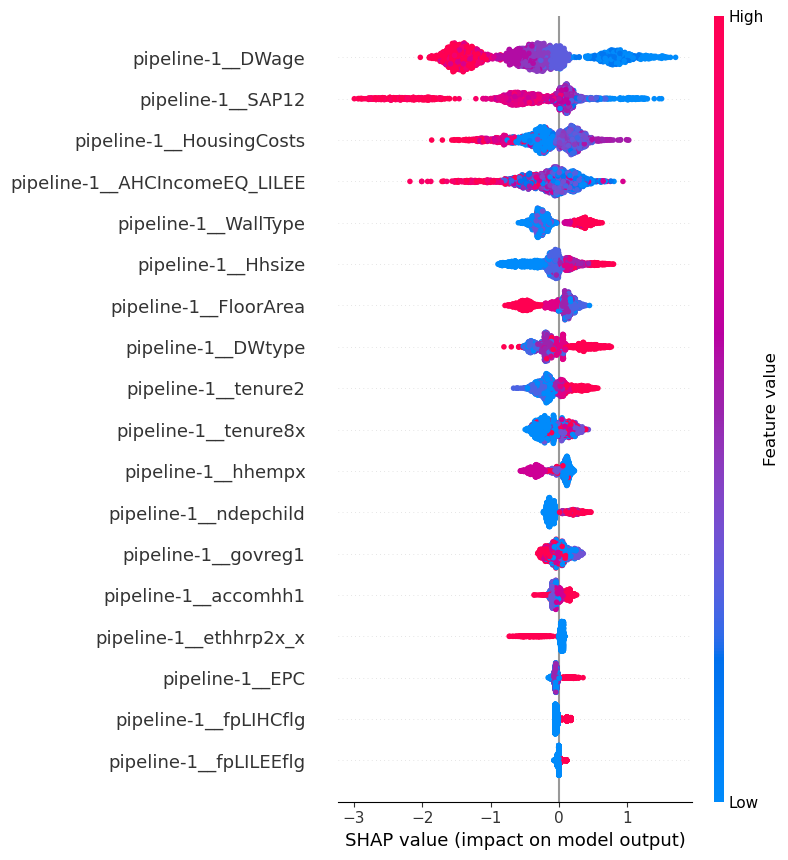

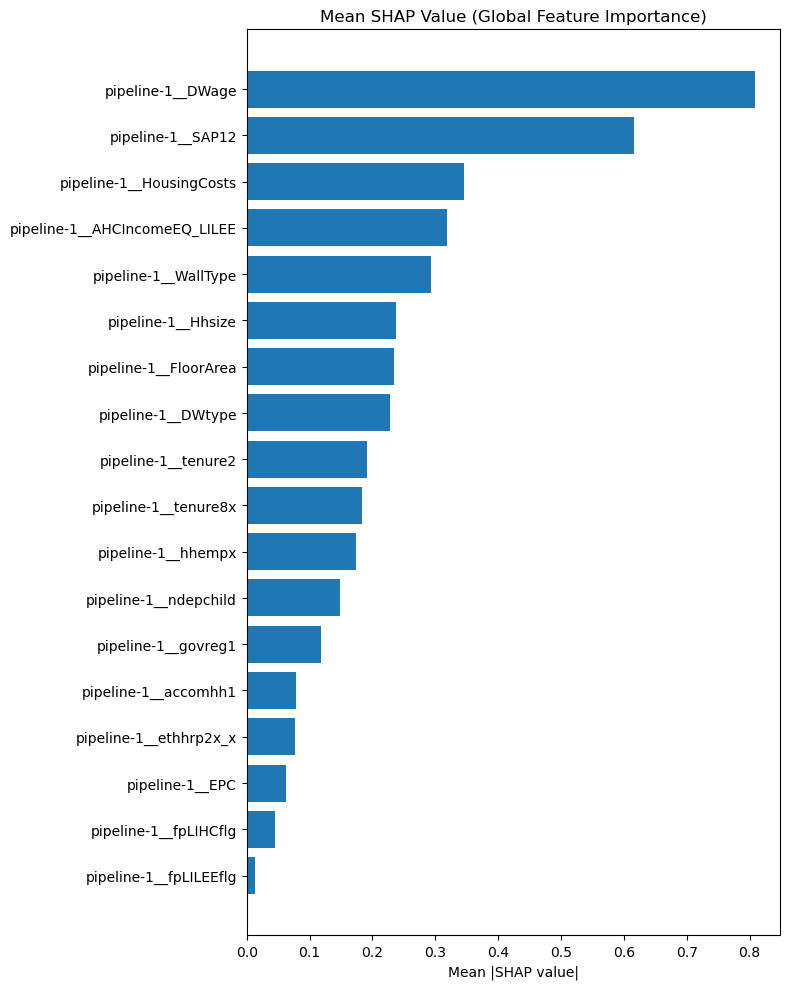

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. DEFINE FEATURE SET
# -----------------------------
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",
    "fpLILEEflg","fpLIHCflg","HousingCosts",
]

# -----------------------------
# 2. BUILD SHAP INPUTS (do NOT overwrite X_train/X_test)
# -----------------------------
X_train_shap = X_train[list_census_proxy].copy()
y_train_shap = y_train.copy()

X_test_shap = X_test[list_census_proxy].copy()
y_test_shap = y_test.copy()

# -----------------------------
# 3. EXTRACT MODEL + PREPROCESSOR
# -----------------------------
xgb_model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Transform X_test into numeric matrix for SHAP
X_test_transformed = preprocessor.transform(X_test_shap)

# -----------------------------
# 4. SHAP EXPLAINER + VALUES
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# -----------------------------
# 5. SHAP SUMMARY PLOT
# -----------------------------
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

# -----------------------------
# 6. MEAN ABSOLUTE SHAP VALUE PLOT
# -----------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(shap_importance["feature"], shap_importance["mean_abs_shap"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Mean SHAP Value (Global Feature Importance)")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# SHAP RESULTS TABLE (clean formatting)
# -----------------------------
shap_direction = (
    pd.DataFrame({
        "Feature": feature_names,
        "Mean SHAP (Direction)": shap_values.mean(axis=0),
        "Mean |SHAP| (Importance)": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("Mean |SHAP| (Importance)", ascending=False)
    .reset_index(drop=True)
)

# Round values for presentation
shap_direction = shap_direction.round(4)

# Convert to a tidy table for Results section
results_table = shap_direction.head(20).style.format({
    "Mean SHAP (Direction)": "{:.4f}",
    "Mean |SHAP| (Importance)": "{:.4f}"
}).set_properties(**{
    "text-align": "left",
    "border": "1px solid #ccc",
    "padding": "4px"
}).set_table_styles([
    {"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#f2f2f2")]},
    {"selector": "td", "props": [("border", "1px solid #ddd")]}
])

results_table


,Feature,Mean SHAP (Direction),Mean |SHAP| (Importance)
0,pipeline-1__DWage,-0.4827,0.8080
1,pipeline-1__SAP12,-0.4189,0.6165
2,pipeline-1__HousingCosts,-0.1480,0.3455
3,pipeline-1__AHCIncomeEQ_LILEE,-0.1733,0.3191
4,pipeline-1__WallType,-0.1218,0.2932
5,pipeline-1__Hhsize,-0.0980,0.2377
6,pipeline-1__FloorArea,-0.0733,0.2345
7,pipeline-1__DWtype,-0.0622,0.2287
8,pipeline-1__tenure2,-0.0889,0.1910
9,pipeline-1__tenure8x,-0.0782,0.1838


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# CLEAN FEATURE NAMES
# -----------------------------
clean_feature_names = [name.split("__")[-1] for name in feature_names]

# -----------------------------
# BUILD RESULTS TABLE
# -----------------------------
shap_table = (
    pd.DataFrame({
        "Feature": clean_feature_names,
        "Mean SHAP (Direction)": shap_values.mean(axis=0),
        "Mean |SHAP| (Importance)": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("Mean |SHAP| (Importance)", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

# -----------------------------
# NICE PRESENTATION FOR RESULTS
# -----------------------------
styled_table = (
    shap_table.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "padding": "6px",
            "border": "1px solid #ccc"
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("font-weight", "bold"),
                ("background-color", "#f2f2f2"),
                ("padding", "6px"),
                ("border", "1px solid #ccc")
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #ddd")
            ]}
        ])
        .format({
            "Mean SHAP (Direction)": "{:.4f}",
            "Mean |SHAP| (Importance)": "{:.4f}"
        })
)

styled_table


Feature,Mean SHAP (Direction),Mean |SHAP| (Importance)
DWage,-0.4827,0.8080
SAP12,-0.4189,0.6165
HousingCosts,-0.1480,0.3455
AHCIncomeEQ_LILEE,-0.1733,0.3191
WallType,-0.1218,0.2932
Hhsize,-0.0980,0.2377
FloorArea,-0.0733,0.2345
DWtype,-0.0622,0.2287
tenure2,-0.0889,0.1910
tenure8x,-0.0782,0.1838


In [ ]:
summary = df_damp_model.groupby('dampalfm')[[
    'DWage','WallType','FloorArea','SAP12','EPC',
    'govreg1','tenure2','tenure8x','fpLILEEflg','fpLIHCflg','HousingCosts',
    'Hhsize','ndepchild','AHCIncomeEQ_LILEE','hhempx','ethhrp2x_x'
]].describe(include='all')

summary


DWage                                              WallType  \
            count      mean       std  min  25%  50%  75%  max    count   
dampalfm                                                                  
0         10184.0  5.763943  2.365762  1.0  4.0  5.0  8.0  9.0  10184.0   
1           388.0  3.430412  1.822286  1.0  2.0  3.0  5.0  9.0    388.0   

                    ... hhempx      ethhrp2x_x                                \
              mean  ...    75%  max      count      mean       std  min  25%   
dampalfm            ...                                                        
0         1.981049  ...    3.0  4.0    10184.0  1.097899  0.297192  1.0  1.0   
1         3.167526  ...    3.0  4.0      388.0  1.115979  0.320614  1.0  1.0   

                         
          50%  75%  max  
dampalfm                 
0         1.0  1.0  2.0  
1         1.0  1.0  2.0  

[2 rows x 128 columns]

In [ ]:
# --- 1. Identify the damp/mould/condensation variable automatically ---
damp_cols = [col for col in df_damp_model.columns
             if any(key in col.lower() for key in ['damp','mould','mold','cond'])]

print("Detected damp-related columns:", damp_cols)

# --- 2. Stop if none found ---
if len(damp_cols) == 0:
    raise ValueError("No damp/mould/condensation variable found in df_damp_model.")

# --- 3. Use the first detected damp variable ---
damp_var = damp_cols[0]
print("Using damp variable:", damp_var)

# --- 4. Generate descriptive comparison table ---
cols_to_describe = [
    'DWage','WallType','FloorArea','SAP12','EPC',
    'govreg1','tenure2','tenure8x','fpLILEEflg','fpLIHCflg','HousingCosts',
    'Hhsize','ndepchild','AHCIncomeEQ_LILEE','hhempx','ethhrp2x_x'
]

# Keep only columns that actually exist in your dataset
cols_available = [c for c in cols_to_describe if c in df_damp_model.columns]

summary = df_damp_model.groupby(damp_var)[cols_available].describe(include='all')
summary



Detected damp-related columns: ['dampalfm']
Using damp variable: dampalfm


DWage                                              WallType  \
            count      mean       std  min  25%  50%  75%  max    count   
dampalfm                                                                  
0         10184.0  5.763943  2.365762  1.0  4.0  5.0  8.0  9.0  10184.0   
1           388.0  3.430412  1.822286  1.0  2.0  3.0  5.0  9.0    388.0   

                    ... hhempx      ethhrp2x_x                                \
              mean  ...    75%  max      count      mean       std  min  25%   
dampalfm            ...                                                        
0         1.981049  ...    3.0  4.0    10184.0  1.097899  0.297192  1.0  1.0   
1         3.167526  ...    3.0  4.0      388.0  1.115979  0.320614  1.0  1.0   

                         
          50%  75%  max  
dampalfm                 
0         1.0  1.0  2.0  
1         1.0  1.0  2.0  

[2 rows x 128 columns]

In [ ]:
df_damp_model.columns


Index(['fpLILEEflg', 'AHCIncomeEQ_LILEE', 'fpfullinc', 'fuelexpn',
       'FuelCosteqFactor', 'EqAHCincDeciles_LILEE', 'elecmop', 'gasmop',
       'aagph2021_x', 'FPGAP_LILEE',
       ...
       'sap12', 'sap412', 'rdsap09', 'EPceeb12e', 'EPceir12e', 'EPceib12e',
       'Equivalised fuel costs', 'Equivalised AHC income',
       'household_income_threshold', 'fpLIHCflg'],
      dtype='object', length=183)

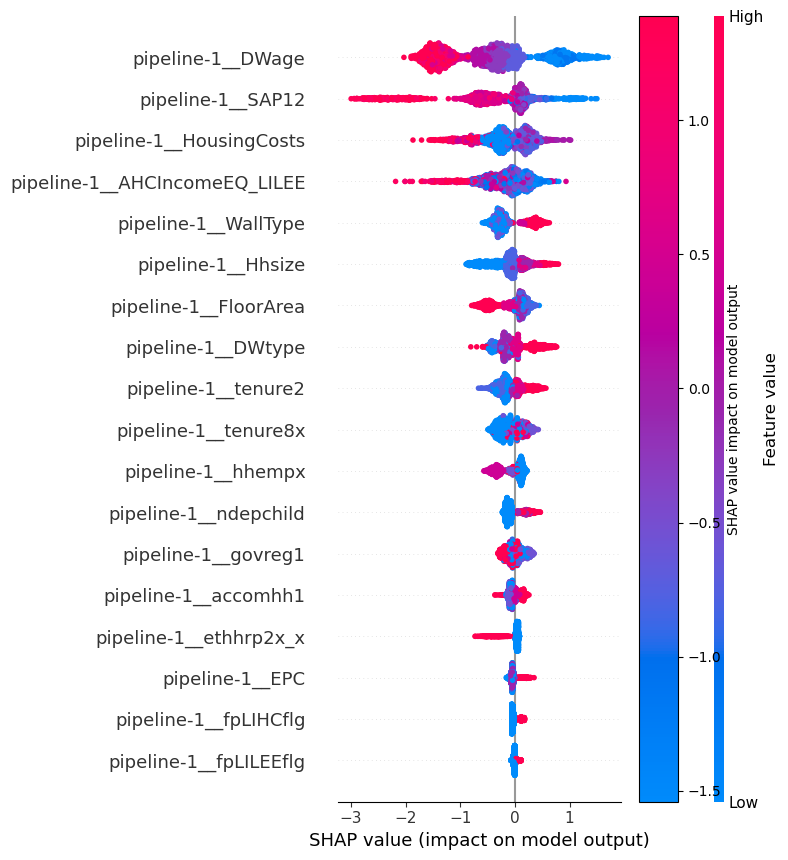

In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------------
# 1. DEFINE FEATURE SET
# -----------------------------
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",
    "fpLILEEflg","fpLIHCflg","HousingCosts",
]

# -----------------------------
# 2. BUILD TRAIN / TEST USING SAME COLUMNS
# -----------------------------
X_train = X_train[list_census_proxy].copy()
y_train = y_train.copy()

X_test = X_test[list_census_proxy].copy()
y_test = y_test.copy()

# -----------------------------
# 3. EXTRACT MODEL + PREPROCESSOR
# -----------------------------
xgb_model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Transform X_test into numeric matrix for SHAP
X_test_transformed = preprocessor.transform(X_test)

# -----------------------------
# 4. SHAP EXPLAINER + VALUES
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# -----------------------------
# 5. SHAP SUMMARY PLOT + COLOUR SCALE
# -----------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

# Add colour bar scale
cbar = plt.colorbar()
cbar.set_label("SHAP value impact on model output")

plt.show()


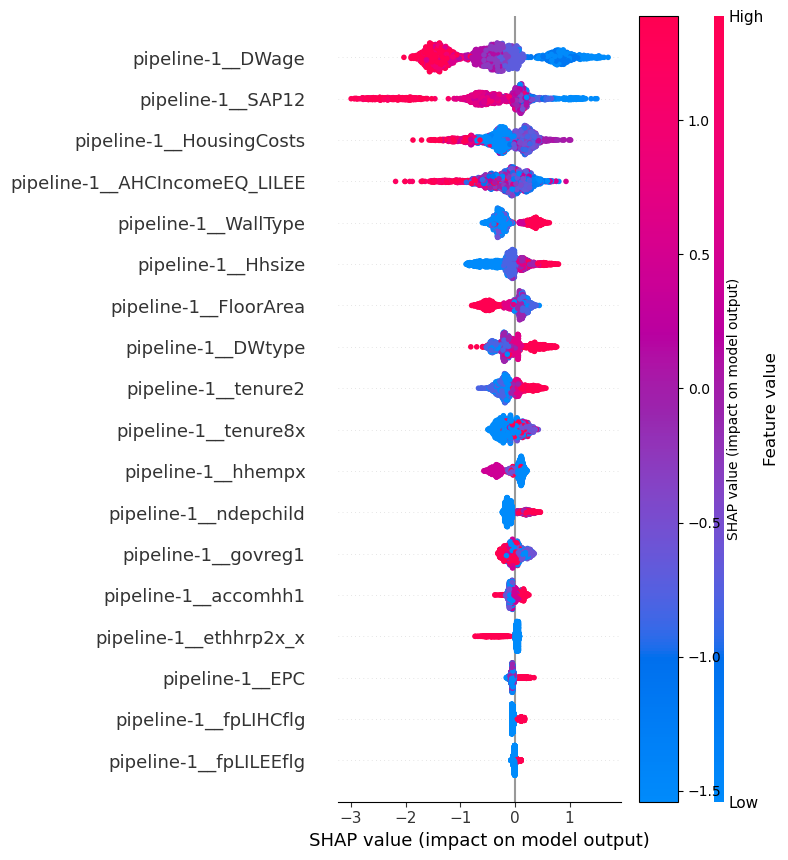

In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------------
# 1. DEFINE FEATURE SET
# -----------------------------
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",
    "fpLILEEflg","fpLIHCflg","HousingCosts",
]

# -----------------------------
# 2. BUILD TRAIN / TEST USING SAME COLUMNS
# -----------------------------
X_train = X_train[list_census_proxy].copy()
y_train = y_train.copy()

X_test = X_test[list_census_proxy].copy()
y_test = y_test.copy()

# -----------------------------
# 3. EXTRACT MODEL + PREPROCESSOR
# -----------------------------
xgb_model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Transform X_test into numeric matrix for SHAP
X_test_transformed = preprocessor.transform(X_test)

# -----------------------------
# 4. SHAP EXPLAINER + VALUES
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# -----------------------------
# 5. SHAP SUMMARY PLOT + COLOUR SCALE
# -----------------------------
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False   # allows adding a colour bar
)

# Add colour bar scale
cbar = plt.colorbar()
cbar.set_label("SHAP value (impact on model output)")

plt.show()


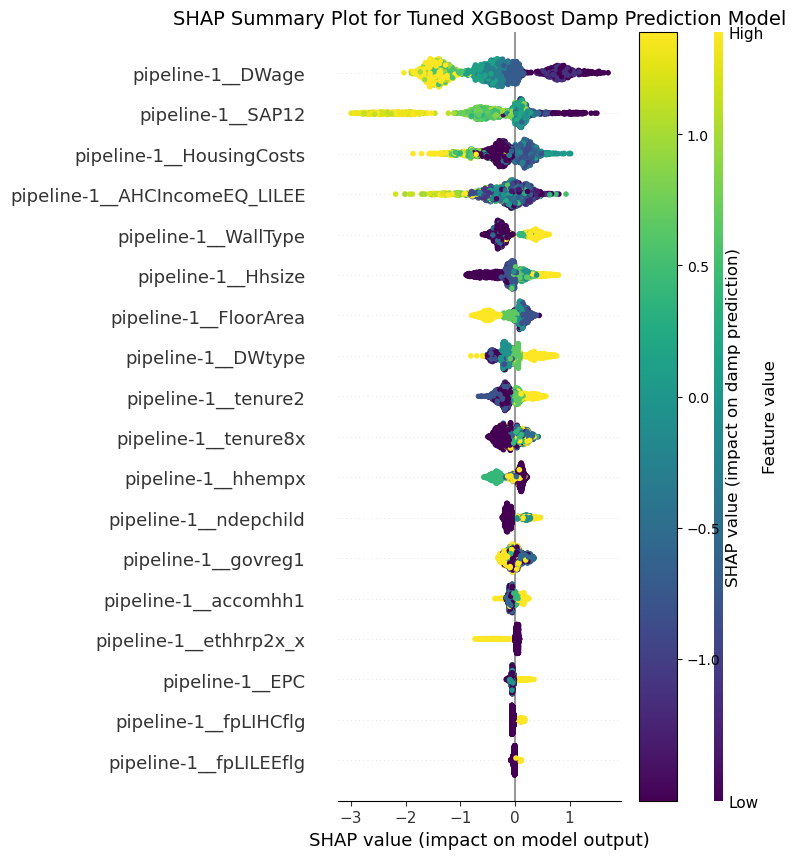

In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------------
# 1. PRETTY FEATURE NAMES (optional but highly recommended)
# -----------------------------
pretty_names = {
    "ethhrp2x_x": "Ethnicity",
    "Hhsize": "Household Size",
    "ndepchild": "Dependent Children",
    "DWtype": "Dwelling Type",
    "DWage": "Dwelling Age",
    "WallType": "Wall Construction",
    "FloorArea": "Floor Area",
    "govreg1": "Region",
    "AHCIncomeEQ_LILEE": "Low Income (LILEE)",
    "tenure8x": "Tenure",
    "accomhh1": "Household Composition",
    "hhempx": "Employment Status",
    "SAP12": "Energy Efficiency (SAP12)",
    "EPC": "Energy Performance Certificate",
    "tenure2": "Tenure (Alt)",
    "fpLILEEflg": "Fuel Poverty (LILEE)",
    "fpLIHCflg": "Fuel Poverty (LIHC)",
    "HousingCosts": "Housing Costs",
}

feature_names_pretty = [pretty_names.get(f, f) for f in feature_names]

# -----------------------------
# 2. SHAP SUMMARY PLOT (AMAZING VERSION)
# -----------------------------
plt.figure(figsize=(14, 9))  # Bigger, cleaner figure

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names_pretty,
    sort=True,          # Sort by mean absolute SHAP value
    cmap="viridis",     # Professional colour map
    show=False          # Allows adding colour bar
)

# -----------------------------
# 3. ADD COLOUR SCALE
# -----------------------------
cbar = plt.colorbar()
cbar.set_label("SHAP value (impact on damp prediction)", fontsize=12)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])  # Adjust depending on your SHAP range

# -----------------------------
# 4. TITLE + TIGHT LAYOUT
# -----------------------------
plt.title("SHAP Summary Plot for Tuned XGBoost Damp Prediction Model", fontsize=14)
plt.tight_layout()

# -----------------------------
# 5. SAVE HIGH-RES VERSION
# -----------------------------
plt.savefig("shap_summary_highres.png", dpi=300, bbox_inches="tight")

plt.show()


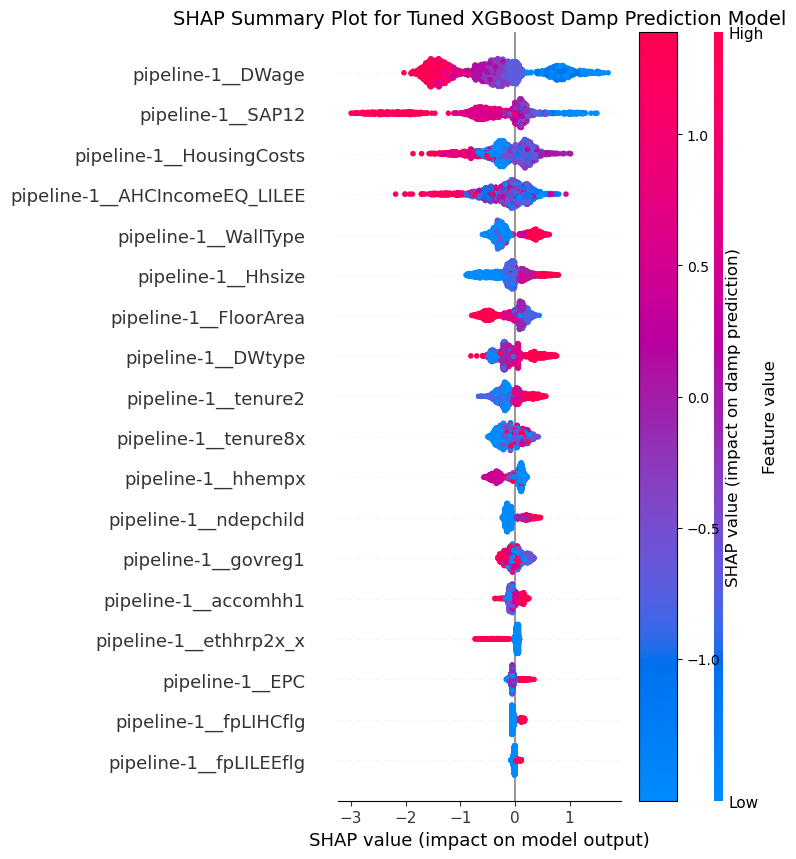

In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------------
# 1. PRETTY FEATURE NAMES
# -----------------------------
pretty_names = {
    "ethhrp2x_x": "Ethnicity",
    "Hhsize": "Household Size",
    "ndepchild": "Dependent Children",
    "DWtype": "Dwelling Type",
    "DWage": "Dwelling Age",
    "WallType": "Wall Construction",
    "FloorArea": "Floor Area",
    "govreg1": "Region",
    "AHCIncomeEQ_LILEE": "Low Income (LILEE)",
    "tenure8x": "Tenure",
    "accomhh1": "Household Composition",
    "hhempx": "Employment Status",
    "SAP12": "Energy Efficiency (SAP12)",
    "EPC": "Energy Performance Certificate",
    "tenure2": "Tenure (Alt)",
    "fpLILEEflg": "Fuel Poverty (LILEE)",
    "fpLIHCflg": "Fuel Poverty (LIHC)",
    "HousingCosts": "Housing Costs",
}

feature_names_pretty = [pretty_names.get(f, f) for f in feature_names]

# -----------------------------
# 2. SHAP SUMMARY PLOT (ORIGINAL COLOURS)
# -----------------------------
plt.figure(figsize=(14, 9))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names_pretty,
    sort=True,      # sort by mean absolute SHAP value
    show=False      # allows adding colour bar
)

# -----------------------------
# 3. ADD COLOUR SCALE
# -----------------------------
cbar = plt.colorbar()
cbar.set_label("SHAP value (impact on damp prediction)", fontsize=12)

# Optional: adjust ticks depending on your SHAP range
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

# -----------------------------
# 4. TITLE + TIGHT LAYOUT
# -----------------------------
plt.title("SHAP Summary Plot for Tuned XGBoost Damp Prediction Model", fontsize=14)
plt.tight_layout()

# -----------------------------
# 5. SAVE HIGH-RES VERSION
# -----------------------------
plt.savefig("shap_summary_original_colours.png", dpi=300, bbox_inches="tight")

plt.show()


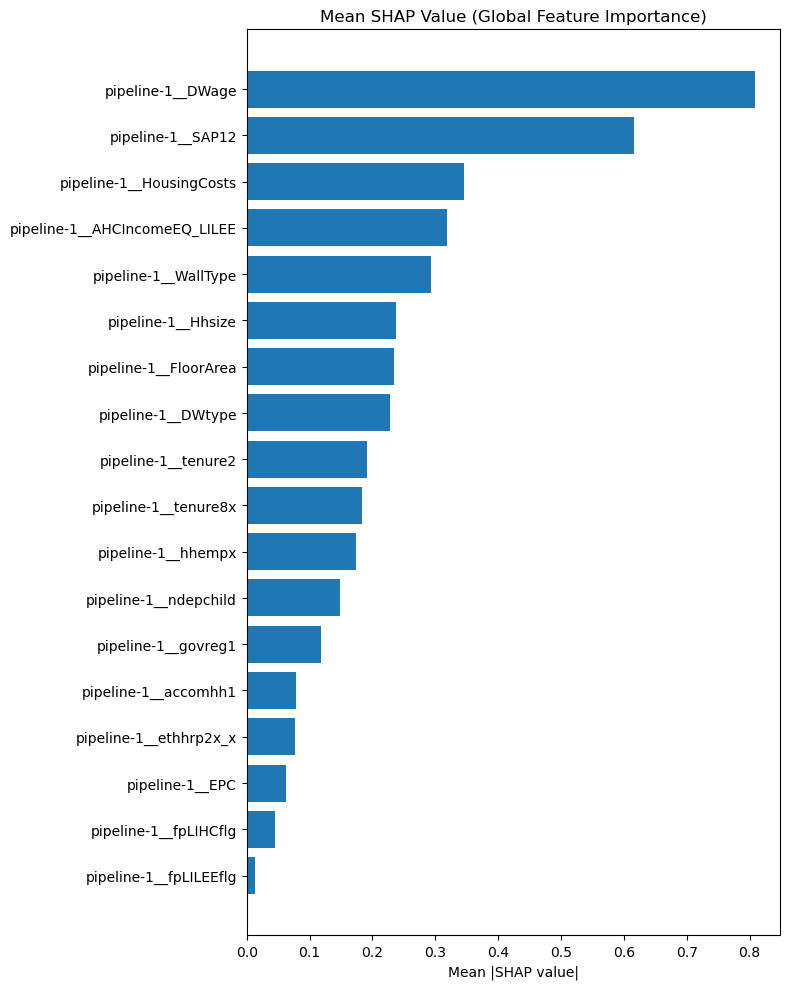

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. DEFINE FEATURE SET
# -----------------------------
list_census_proxy = [
    "ethhrp2x_x",
    "Hhsize", "ndepchild",
    "DWtype", "DWage", "WallType", "FloorArea",
    "govreg1", "AHCIncomeEQ_LILEE",
    "tenure8x","accomhh1","hhempx",
    "SAP12","EPC",
    "tenure2",
    "fpLILEEflg","fpLIHCflg","HousingCosts",
]

# -----------------------------
# 2. BUILD SHAP INPUTS (do NOT overwrite X_train/X_test)
# -----------------------------
X_train_shap = X_train[list_census_proxy].copy()
y_train_shap = y_train.copy()

X_test_shap = X_test[list_census_proxy].copy()
y_test_shap = y_test.copy()

# -----------------------------
# 3. EXTRACT MODEL + PREPROCESSOR
# -----------------------------
xgb_model = xgb_pipeline.named_steps["model"]
preprocessor = xgb_pipeline.named_steps["preprocessor"]

# Transform X_test into numeric matrix for SHAP
X_test_transformed = preprocessor.transform(X_test_shap)

# -----------------------------
# 4. SHAP EXPLAINER + VALUES
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# Correct feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

#-----------------
# 6. MEAN ABSOLUTE SHAP VALUE PLOT
# -----------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(shap_importance["feature"], shap_importance["mean_abs_shap"])
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Mean SHAP Value (Global Feature Importance)")
plt.tight_layout()
plt.show()